# Load Embryonic Data

In [12]:
import scanpy as sc

# Load the Embryonic h5ad file
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 156726 × 1024
    obs: 'Age', 'ClassAnn', 'Souporcell', 'Subclass', 'Superclass', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'total_genes', 'total_UMIs', 'sample_id', 'celltype', 'cluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'Chromosome', 'End', 'gene_name', 'Start', 'Strand', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_condition', 'celltype_color_map', 'celltype_colors', 'citati

In [13]:
print(type(adata.uns["celltype_colors"]))

<class 'numpy.ndarray'>


In [21]:
# adata.obs.rename(columns={"CellType": "celltype"}, inplace=True)
# adata.write_h5ad("/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad", compression="gzip")

# # UMAP
# if "X_UMAP" in adata.obsm and "X_umap" not in adata.obsm:
#     print("Renaming UMAP coordinates from 'X_UMAP' to 'X_umap' for consistency.")
#     adata.obsm["X_umap"] = adata.obsm["X_UMAP"].copy()
#     del adata.obsm["X_UMAP"]

# # tSNE（表記ゆれもついでに対応）
# if "X_tSNE" in adata.obsm and "X_tsne" not in adata.obsm:
#     print("Renaming tSNE coordinates from 'X_tSNE' to 'X_tsne' for consistency.")
#     adata.obsm["X_tsne"] = adata.obsm["X_tSNE"].copy()
#     del adata.obsm["X_tSNE"]

adata.write_h5ad('/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad', compression="gzip")

In [11]:
adata.obs.loc[
    adata.obs["Superclass"] == "Vascular perivascular",
    "celltype"
].unique()

['Perivascular fibroblast', 'Smooth muscle cell, mature', 'Pericyte', 'Smooth muscle cell', 'ChP Perivascular', 'ChP Pericyte']
Categories (115, object): ['Anteromedial cerebral pole glioblast', 'Anteromedial cerebral pole radial glia', 'Arachnoid', 'Arachnoid barrier', ..., 'Venous capillary', 'Venous lymphatic-like', 'Venous lymphatic-like - non-leptomeningeal', 'Ventral forebrain radial glia']

In [14]:
# import numpy as np
# import pandas as pd
# import matplotlib.colors as mcolors
# import glasbey
# from sklearn.metrics import pairwise_distances
# from skimage import color

# # -------------------------
# # 0. 前処理（安定化）
# # -------------------------
# adata.obs["celltype"] = adata.obs["celltype"].astype("category").cat.remove_unused_categories()
# adata.obs["Superclass"] = adata.obs["Superclass"].astype("category").cat.remove_unused_categories()

# celltypes = adata.obs["celltype"].cat.categories.tolist()
# superclasses = adata.obs["Superclass"].cat.categories.tolist()
# n_ct = len(celltypes)

# # celltype -> [Superclass...]（複数OK, NaNはUnknownへ）
# df = adata.obs[["celltype", "Superclass"]].copy()
# df["celltype"] = df["celltype"].astype(str)
# df["Superclass"] = df["Superclass"].astype(str)

# # NaN文字や空文字対策
# df.loc[df["Superclass"].isin(["nan", "NaN", "None", ""]), "Superclass"] = "Unknown"
# df["Superclass"] = df["Superclass"].str.strip()

# ct2supers = (
#     df.drop_duplicates()
#       .groupby("celltype")["Superclass"]
#       .apply(lambda x: sorted(set(x.tolist())))
#       .to_dict()
# )

# # Superclass -> [celltype...]（必要なら後で評価に使える）
# ct_by_super = {s: [] for s in superclasses}
# ct_by_super.setdefault("Unknown", [])

# for ct in celltypes:
#     for s in ct2supers.get(ct, ["Unknown"]):
#         ct_by_super.setdefault(s, [])
#         ct_by_super[s].append(ct)

# # -------------------------
# # 1. 候補色を多めに生成（重要）
# # -------------------------
# oversample = 8               # 6〜12推奨
# M = max(n_ct * oversample, n_ct + 100)

# base = glasbey.create_palette(M)
# rgb = np.array([mcolors.to_rgb(c) if isinstance(c, str) else tuple(c) for c in base], dtype=float)
# lab = color.rgb2lab(rgb.reshape(-1, 1, 3)).reshape(-1, 3)

# # 距離行列（候補同士）
# dist = pairwise_distances(lab)   # (M, M)

# # -------------------------
# # 2. Greedy 選抜：Superclass内の似色回避を最優先
# # -------------------------
# alpha_global = 0.05  # 0ならSuperclass内だけ。0.02〜0.1で軽く全体もばらす

# unused = list(range(M))
# assigned = {}  # celltype -> color_idx
# group_assigned = {s: [] for s in ct_by_super.keys()}  # Superclass -> [color_idx...]

# # 複数Superclassに跨るcelltypeを先に塗る（制約が強いものから）
# def ct_priority(ct):
#     supers = ct2supers.get(ct, ["Unknown"])
#     deg = len(supers)
#     # 所属先のグループ規模が大きいほど先に（詰みを避ける）
#     max_group = max(len(ct_by_super.get(s, [])) for s in supers)
#     return (-deg, -max_group)

# order = sorted(celltypes, key=ct_priority)

# for ct in order:
#     supers = ct2supers.get(ct, ["Unknown"])
#     constraint_sets = [group_assigned.get(s, []) for s in supers]

#     u = np.array(unused, dtype=int)

#     # primary: within-superclass separation（所属する全Superclassに対する最悪ケースを最大化）
#     primary = np.full(len(u), np.inf, dtype=float)
#     any_constraint = False
#     for chosen_idxs in constraint_sets:
#         if len(chosen_idxs) == 0:
#             continue
#         any_constraint = True
#         chosen_idxs = np.array(chosen_idxs, dtype=int)
#         dmin = dist[np.ix_(u, chosen_idxs)].min(axis=1)
#         primary = np.minimum(primary, dmin)

#     chosen_all = np.array(list(assigned.values()), dtype=int)

#     if not any_constraint:
#         # 初期フェーズ：全体でなるべく離す（安定化）
#         if len(chosen_all) == 0:
#             center = lab.mean(axis=0, keepdims=True)
#             d_center = pairwise_distances(lab[u], center).reshape(-1)
#             best = int(u[np.argmax(d_center)])
#         else:
#             dmin_global = dist[np.ix_(u, chosen_all)].min(axis=1)
#             best = int(u[np.argmax(dmin_global)])
#     else:
#         # secondary: global separation（同点タイブレーク）
#         if len(chosen_all) == 0:
#             secondary = np.zeros(len(u), dtype=float)
#         else:
#             secondary = dist[np.ix_(u, chosen_all)].min(axis=1)

#         score = primary + alpha_global * secondary
#         best = int(u[np.argmax(score)])

#     assigned[ct] = best
#     for s in supers:
#         group_assigned.setdefault(s, [])
#         group_assigned[s].append(best)

#     # 未使用から除去（順序保持）
#     unused = [x for x in unused if x != best]

# # -------------------------
# # 3. adataへ登録（欠損ゼロ保証）
# # -------------------------
# missing = set(celltypes) - set(assigned.keys())
# if missing:
#     raise KeyError(f"色が割り当てられていない celltype: {sorted(missing)}")

# celltype_color_dict = {ct: mcolors.to_hex(rgb[idx]) for ct, idx in assigned.items()}
# adata.uns["celltype_colors"] = [celltype_color_dict[ct] for ct in celltypes]



In [5]:

import numpy as np
def to_pylist(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x.tolist()
    return list(x)

# 2) uns の celltype_colors を Python list[str] に正規化
colors = adata.uns.get("celltype_colors", None)
colors = to_pylist(colors)
if colors is None:
    raise KeyError("adata.uns['celltype_colors'] がありません。先に色を作成してください。")


# 3) 「カテゴリ数」と「色数」が一致しているかチェック
cats = list(adata.obs["celltype"].cat.categories)
if len(colors) != len(cats):
    # ここがズレていると、どのみちプロットがおかしくなるので止めるのが安全
    raise ValueError(f"celltype categories={len(cats)} に対して celltype_colors={len(colors)} で不一致です。")
# 4) dict形式の色マップも保存しておく（再ロード後に復元しやすい）
adata.uns["celltype_color_map"] = {ct: col for ct, col in zip(cats, colors)}
# 5) 念のため uns 側も「カテゴリ順のlist」に再代入
adata.uns["celltype_colors"] = [adata.uns["celltype_color_map"][ct] for ct in cats]
# 6) 保存（安全のため一旦別名→rename も可）
adata.write_h5ad('/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad')
print("saved:", '/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad')

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


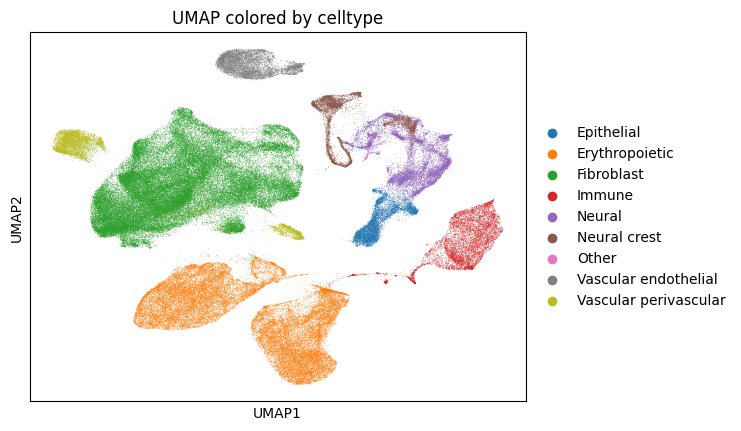

In [7]:
sc.pl.embedding(
        adata,
        basis="UMAP",
        color="Superclass",
        title=f"UMAP colored by celltype"
)

In [2]:
# 階層構造の順番にリスト化
hierarchy_cols = ['Superclass', 'ClassAnn', 'Subclass', 'celltype', 'cell_type']

for col in hierarchy_cols:
    print(f"--- {col} ({len(adata.obs[col].unique())} types) ---")
    # アルファベット順にソートして表示（見やすさのため）
    unique_values = sorted(adata.obs[col].unique().astype(str))
    print(", ".join(unique_values))
    print("\n")

--- Superclass (9 types) ---
Epithelial, Erythropoietic, Fibroblast, Immune, Neural, Neural crest, Other, Vascular endothelial, Vascular perivascular


--- ClassAnn (45 types) ---
Arachnoid, Arachnoid-Dura, Arterial, ChP Definitive, ChP Epithelial, ChP Epithelial progenitor, ChP Fibroblast, ChP Meningeal, ChP Pericyte, ChP Perivascular, Chondrogenic, Definitive, Dura, Endothelial, Epithelial, Fatty acid metabolic, Glioblast, Hindbrain, Intermediate progenitor, Interneuron, Lymphoid, Myeloid, Neural crest progenitor, Neuroblast, Neuron, Oligodendrocyte lineage, Optic, Other, Pericyte, Peripheral neuroblast, Peripheral neuron, Perivascular, Pia, Pinealocyte, Pre-EMT neural crest, Primary, Primary meninx, Primitive, Progenitor, Radial glia, Rathkes pouch, Schwann cell lineage, Smooth muscle cell, Tip cell, Venous


--- Subclass (105 types) ---
Anteromedial cerebral pole glioblast, Anteromedial cerebral pole radial glia, Arachnoid, Arachnoid barrier, Arachnoid-dura border, Arterial capilla

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


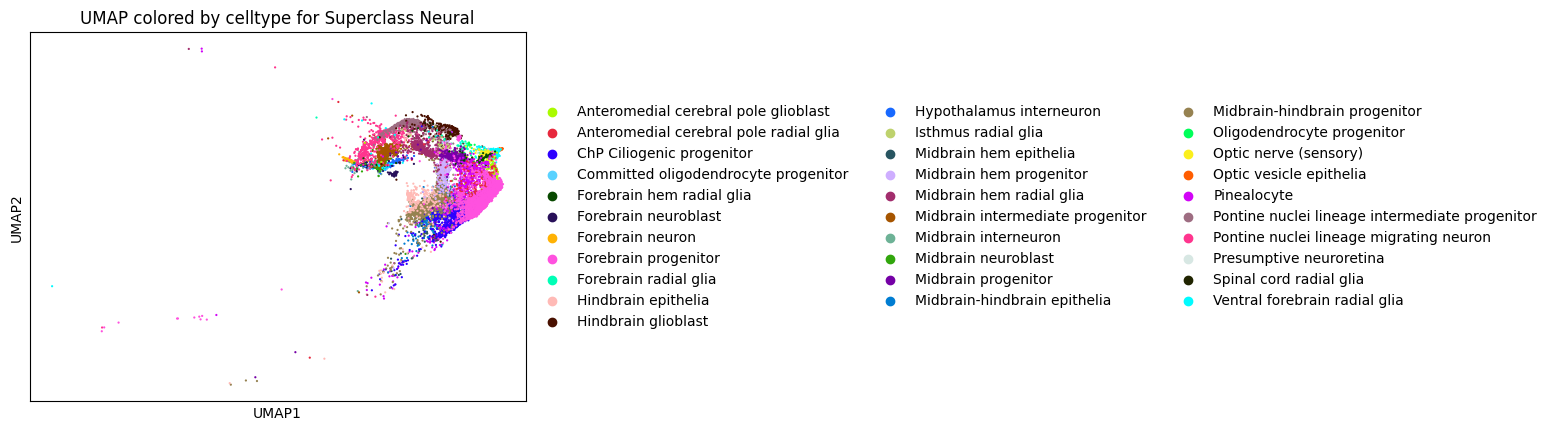

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


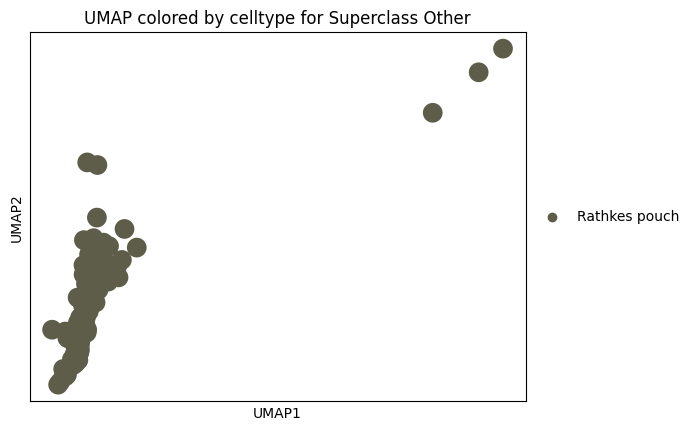

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


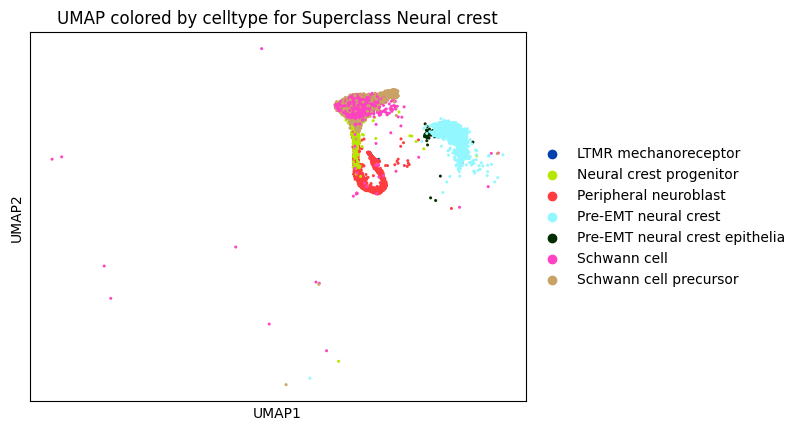

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


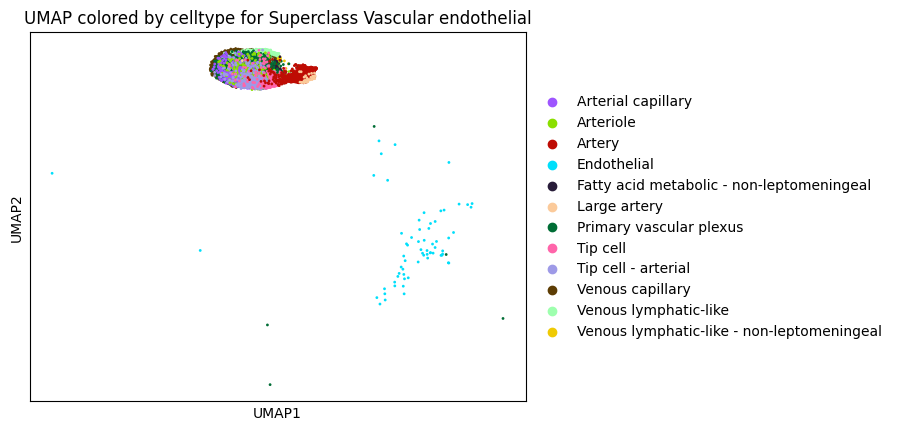

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


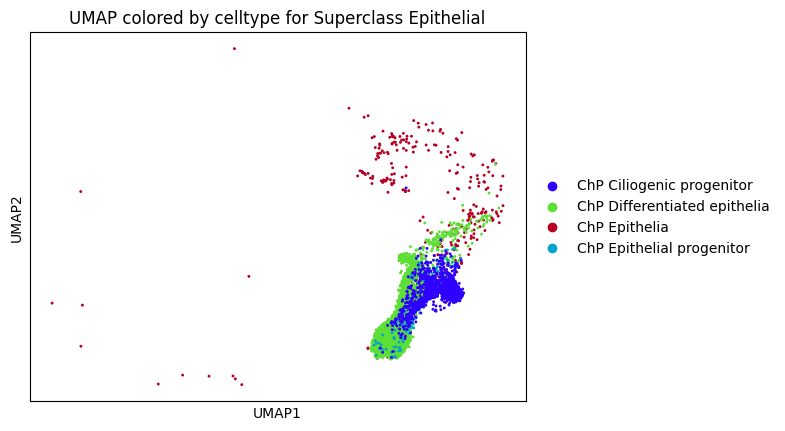

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


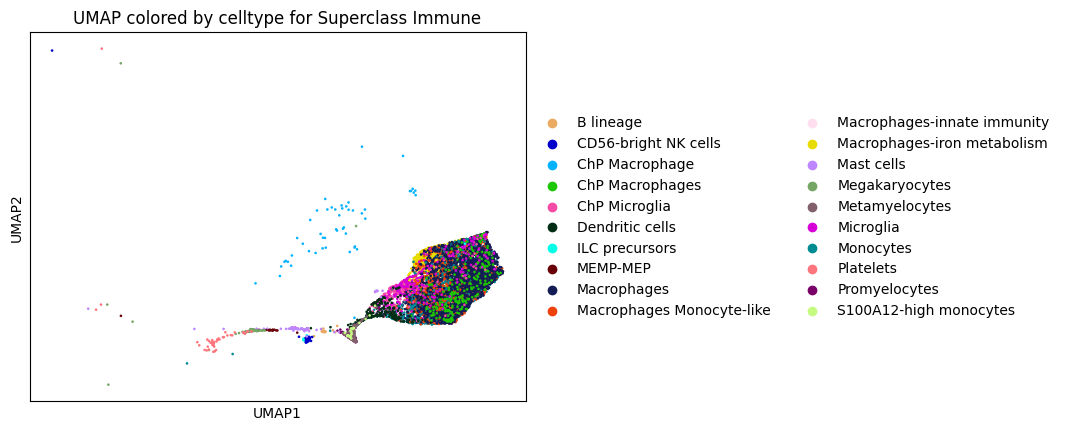

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


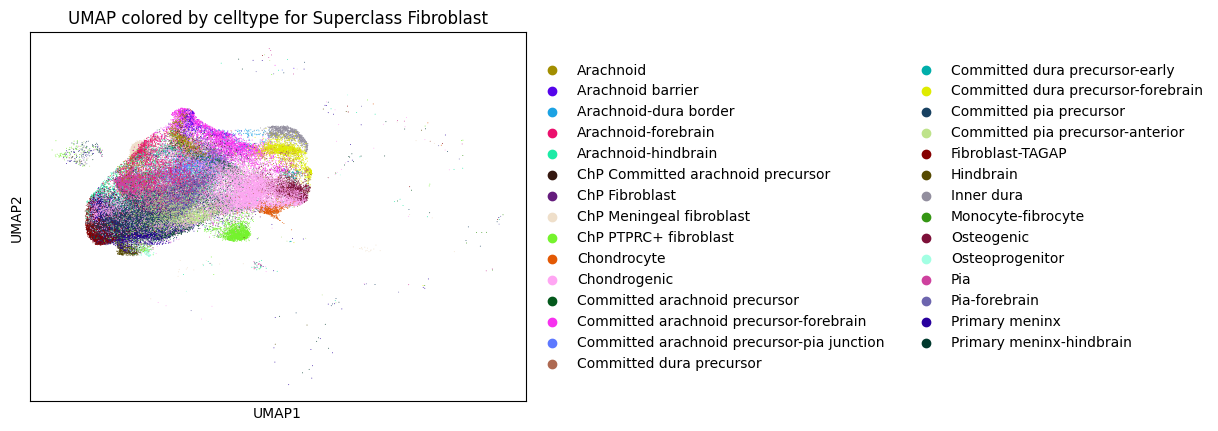

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


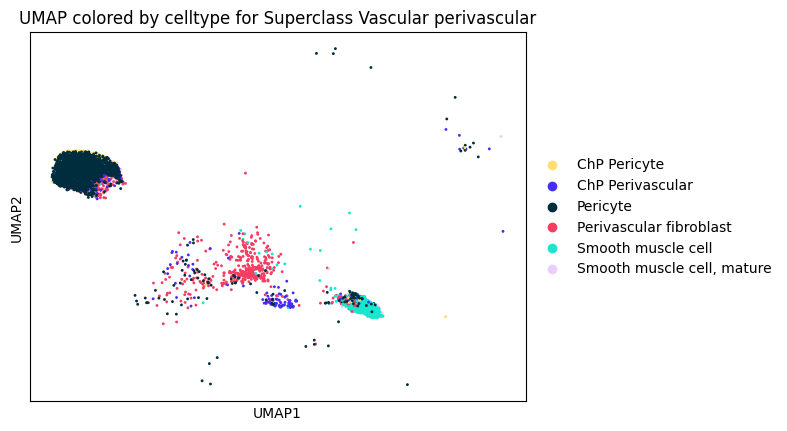

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


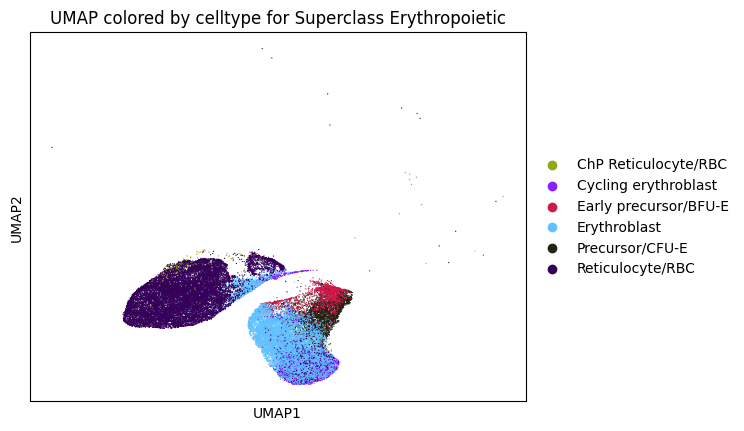

In [20]:
for i in adata.obs["Superclass"].unique():
    sc.pl.embedding(
        adata[adata.obs["Superclass"] == i],
        basis="umap",
        color="celltype",
        legend_loc="right margin",
        title=f"UMAP colored by celltype for Superclass {i}"
    )

In [3]:

for sc_name in adata.obs["Superclass"].astype(str).unique():
    subset = adata[adata.obs["Superclass"].astype(str) == sc_name]
    
    unique_values = sorted(subset.obs["celltype"].astype(str).unique())
    
    print(f"--- {sc_name} ({len(unique_values)} types) ---")
    print(", ".join(unique_values))
    print("\n")

--- Neural (31 types) ---
Anteromedial cerebral pole glioblast, Anteromedial cerebral pole radial glia, ChP Ciliogenic progenitor, Committed oligodendrocyte progenitor, Forebrain hem radial glia, Forebrain neuroblast, Forebrain neuron, Forebrain progenitor, Forebrain radial glia, Hindbrain epithelia, Hindbrain glioblast, Hypothalamus interneuron, Isthmus radial glia, Midbrain hem epithelia, Midbrain hem progenitor, Midbrain hem radial glia, Midbrain intermediate progenitor, Midbrain interneuron, Midbrain neuroblast, Midbrain progenitor, Midbrain-hindbrain epithelia, Midbrain-hindbrain progenitor, Oligodendrocyte progenitor, Optic nerve (sensory), Optic vesicle epithelia, Pinealocyte, Pontine nuclei lineage intermediate progenitor, Pontine nuclei lineage migrating neuron, Presumptive neuroretina, Spinal cord radial glia, Ventral forebrain radial glia


--- Other (1 types) ---
Rathkes pouch


--- Neural crest (7 types) ---
LTMR mechanoreceptor, Neural crest progenitor, Peripheral neurobl

In [2]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc

def _finite_report(mat, label="X"):
    if sp.issparse(mat):
        data = mat.data  # stored entries only
        shape = mat.shape
        nan = int(np.isnan(data).sum())
        posinf = int(np.isposinf(data).sum())
        neginf = int(np.isneginf(data).sum())
        finite = np.isfinite(data)
        mn = float(data[finite].min()) if finite.any() else np.nan
        mx = float(data[finite].max()) if finite.any() else np.nan
        print(f"[{label}] sparse shape={shape}, nnz={mat.nnz}, dtype={data.dtype}, "
              f"nan={nan}, +inf={posinf}, -inf={neginf}, finite_min={mn}, finite_max={mx}")
        return {"nan": nan, "posinf": posinf, "neginf": neginf, "is_sparse": True}
    else:
        X = np.asarray(mat)
        nan = int(np.isnan(X).sum())
        posinf = int(np.isposinf(X).sum())
        neginf = int(np.isneginf(X).sum())
        finite = np.isfinite(X)
        mn = float(X[finite].min()) if finite.any() else np.nan
        mx = float(X[finite].max()) if finite.any() else np.nan
        print(f"[{label}] dense shape={X.shape}, dtype={X.dtype}, "
              f"nan={nan}, +inf={posinf}, -inf={neginf}, finite_min={mn}, finite_max={mx}")
        return {"nan": nan, "posinf": posinf, "neginf": neginf, "is_sparse": False}

def _show_bad_entries(adata_obj, mat, k=15, label="X"):
    print(f"Bad entry examples in {label}:")
    if sp.issparse(mat):
        coo = mat.tocoo()
        bad = ~np.isfinite(coo.data)
        idx = np.where(bad)[0][:k]
        for t in idx:
            i = int(coo.row[t]); j = int(coo.col[t])
            print(f"  cell={adata_obj.obs_names[i]} (i={i})  gene={adata_obj.var_names[j]} (j={j})  value={coo.data[t]}")
        print(f"  showing {len(idx)} / total bad stored entries = {int(bad.sum())}")
    else:
        X = np.asarray(mat)
        bad = ~np.isfinite(X)
        coords = np.argwhere(bad)
        for i, j in coords[:k]:
            i = int(i); j = int(j)
            print(f"  cell={adata_obj.obs_names[i]} (i={i})  gene={adata_obj.var_names[j]} (j={j})  value={X[i, j]}")
        print(f"  showing {min(k, len(coords))} / total bad entries = {int(bad.sum())}")

def _gene_var_and_nnz(X):
    # returns var (dense array), and nnz per gene (dense array)
    if sp.issparse(X):
        Xc = X.tocsr()
        mean = np.array(Xc.mean(axis=0)).ravel()
        mean_sq = np.array(Xc.multiply(Xc).mean(axis=0)).ravel()
        var = mean_sq - mean**2
        nnz = np.array((Xc != 0).sum(axis=0)).ravel()
        return var, nnz
    else:
        Xd = np.asarray(X)
        var = Xd.var(axis=0)
        nnz = (Xd != 0).sum(axis=0)
        return var, nnz

def audit_nan_origin(adata, sc_name="Neural", color_col="celltype"):
    # --- subset ---
    adata_sub = adata[adata.obs["Superclass"] == sc_name].copy()
    print(f"subset Superclass={sc_name}  n_obs={adata_sub.n_obs}  n_vars={adata_sub.n_vars}")

    # --- stage 0: BEFORE scale ---
    r0 = _finite_report(adata_sub.X, label="before scale: adata_sub.X")
    if (r0["nan"] or r0["posinf"] or r0["neginf"]):
        _show_bad_entries(adata_sub, adata_sub.X, label="before scale: adata_sub.X")

    # ついでに layers も見たいなら（存在する場合）
    for key in ["X", "velocity_ode"]:
        if key in adata_sub.layers:
            _finite_report(adata_sub.layers[key], label=f"before scale: layer['{key}']")

    # --- stage 1: AFTER scale (on copy) ---
    adata_scaled = adata_sub.copy()
    sc.pp.scale(adata_scaled, max_value=10)

    r1 = _finite_report(adata_scaled.X, label="after scale: adata_scaled.X")
    if (r1["nan"] or r1["posinf"] or r1["neginf"]):
        _show_bad_entries(adata_scaled, adata_scaled.X, label="after scale: adata_scaled.X")

    # --- decision ---
    introduced_by_scale = (
        (r0["nan"] == 0 and r0["posinf"] == 0 and r0["neginf"] == 0) and
        (r1["nan"] > 0 or r1["posinf"] > 0 or r1["neginf"] > 0)
    )

    if introduced_by_scale:
        print("\n=> NaN/Inf は sc.pp.scale() によって新規に入った可能性が高いです。原因候補を掘ります。")

        # scale 前の “ゼロ分散/非有限分散” 遺伝子を特定（std=0 相当）
        var0, nnz0 = _gene_var_and_nnz(adata_sub.X)
        bad_var = ~np.isfinite(var0)
        zero_var = (var0 == 0)

        print(f"genes with non-finite var BEFORE scale: {int(bad_var.sum())}")
        print(f"genes with zero var BEFORE scale:       {int(zero_var.sum())}")

        # 特に「all-zero（nnz=0）」はゼロ分散の強い原因
        all_zero = (nnz0 == 0)
        print(f"genes with all-zero (nnz=0) BEFORE scale: {int(all_zero.sum())}")

        # 例をいくつか出す
        if bad_var.any():
            idx = np.where(bad_var)[0][:20]
            print("example bad-var genes:", list(adata_sub.var_names[idx]))
        if zero_var.any():
            idx = np.where(zero_var)[0][:20]
            print("example zero-var genes:", list(adata_sub.var_names[idx]))
        if all_zero.any():
            idx = np.where(all_zero)[0][:20]
            print("example all-zero genes:", list(adata_sub.var_names[idx]))

        # 「どんなデータだったから？」に答えるため、ゼロ分散遺伝子の nnz を見せる
        if zero_var.any():
            idx = np.where(zero_var)[0][:50]
            print("\nzero-var genes nnz (first up to 50):")
            for j in idx:
                print(f"  {adata_sub.var_names[j]}  nnz={int(nnz0[j])}")

    else:
        if (r0["nan"] or r0["posinf"] or r0["neginf"]):
            print("\n=> NaN/Inf は scale 前（= 元データ or それ以前の処理）ですでに入っています。")
        else:
            print("\n=> scale 前後とも NaN/Inf は検出されませんでした（別の場所が原因か、再現条件が違う可能性）。")

    return adata_sub  # 必要なら返す

# ---- 実行（SuperClassを変えたいなら sc_name を変更）----
audit_nan_origin(adata, sc_name="Neural")

subset Superclass=Neural  n_obs=11800  n_vars=1024
[before scale: adata_sub.X] dense shape=(11800, 1024), dtype=float32, nan=0, +inf=0, -inf=0, finite_min=-1.8162227869033813, finite_max=383.5395812988281


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


[after scale: adata_scaled.X] dense shape=(11800, 1024), dtype=float32, nan=495600, +inf=0, -inf=0, finite_min=-2.605806350708008, finite_max=10.0
Bad entry examples in after scale: adata_scaled.X:
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000211677 (j=486)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000117560 (j=497)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000111537 (j=498)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000143185 (j=511)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000186652 (j=521)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000197253 (j=534)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000274536 (j=567)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000173237 (j=580)  value=nan
  cell=10X352_2_AB_1:ACATGCACACATACTGx (i=0)  gene=ENSG00000163599 (j=706)  value=nan
  cell=10X352_2_AB_1:ACATGCA

AnnData object with n_obs × n_vars = 11800 × 1024
    obs: 'Age', 'ClassAnn', 'Souporcell', 'Subclass', 'Superclass', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'total_genes', 'total_UMIs', 'sample_id', 'celltype', 'cluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'Chromosome', 'End', 'gene_name', 'Start', 'Strand', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_condition', 'celltype_colors', 'citation', 'hvg', 'log1p', 'o